In [ ]:
# Tarik repositori backend kalian langsung ke dalam Colab!
# Jika sudah Clone, maka tidak perlu
!git lfs install
!git clone https://huggingface.co/spaces/freshlyTeam/Freshly_api

In [ ]:
# 1. Setup Environment Keras 2
!pip install tf-keras -q
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

print(f"TensorFlow Version: {tf.__version__}")
print("Legacy Keras (v2) berhasil diaktifkan! Silakan lanjut ke Cell 2.")

TensorFlow Version: 2.20.0
Legacy Keras (v2) berhasil diaktifkan! Silakan lanjut ke Cell 2.


In [ ]:
# 2. Definisi Custom Layer
class CustomLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.gamma = self.add_weight(name='gamma', shape=(1, 1, 1, input_shape[-1]),
                                     initializer='ones', trainable=True)
        super(CustomLayer, self).build(input_shape)
    def call(self, x):
        return x * self.gamma
    def get_config(self):
        return super(CustomLayer, self).get_config()

class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(
            filters=1, kernel_size=kernel_size, padding='same',
            activation='sigmoid', name="spatial_attention_conv"
        )
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        spatial_mask = self.conv(concat)
        return inputs * spatial_mask
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [ ]:
# 3. Load Model dari Folder SavedModel
# Pastikan nama foldernya sesuai dengan yang ada di dalam Freshly_api
path_ke_model = "Freshly_api/paprika_saved_model" # <--- Sesuaikan jika nama foldernya beda

print("Memuat model dari SavedModel...")
model_freshly_tuning = tf.keras.models.load_model(
    path_ke_model,
    compile=False,
    custom_objects={'CustomLayer': CustomLayer, 'SpatialAttention': SpatialAttention}
)
print("Model berhasil dimuat! Berikut ringkasan arsitekturnya:")
model_freshly_tuning.summary()

Memuat model dari SavedModel...
Model berhasil dimuat! Berikut ringkasan arsitekturnya:
Model: "freshly_paprika_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_image (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 color_branch (Conv2D)       (None, 224, 224, 32)         128       ['input_image[0][0]']         
                                                                                                  
 texture_branch (Conv2D)     (None, 224, 224, 32)         896       ['input_image[0][0]']         
                                                                                                  
 shape_branch (Conv2D)       (None, 224, 224, 32)         2432      ['input_image[0][0]']

In [ ]:
# 4. Fungsi Preprocessing & Grad-CAM
def get_and_preprocess_image(img_path, size):
    img = tf.keras.utils.load_img(img_path, target_size=size)
    array = tf.keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)

    # Normalisasi ImageNet
    MEAN_np = np.array([0.485, 0.456, 0.406])
    STD_np = np.array([0.229, 0.224, 0.225])
    array_norm = (array / 255.0 - MEAN_np) / STD_np
    return array_norm, img

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]

    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds[0], pred_index.numpy()

def display_gradcam(img, heatmap, preds, pred_index, class_names, alpha=0.6):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.size[0], img.size[1]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + tf.keras.utils.img_to_array(img)
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Gambar Asli")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    pred_label = class_names[pred_index]
    confidence = preds[pred_index] * 100
    plt.title(f"Fokus model pada objek\nPrediksi: {pred_label} ({confidence:.2f}%)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


Menjalankan Inference dan Grad-CAM Paprika untuk 3 Gambar...

Menganalisis gambar: PAPRIKA_MATANG.jpeg...


/tmp/ipykernel_2811/265145812.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


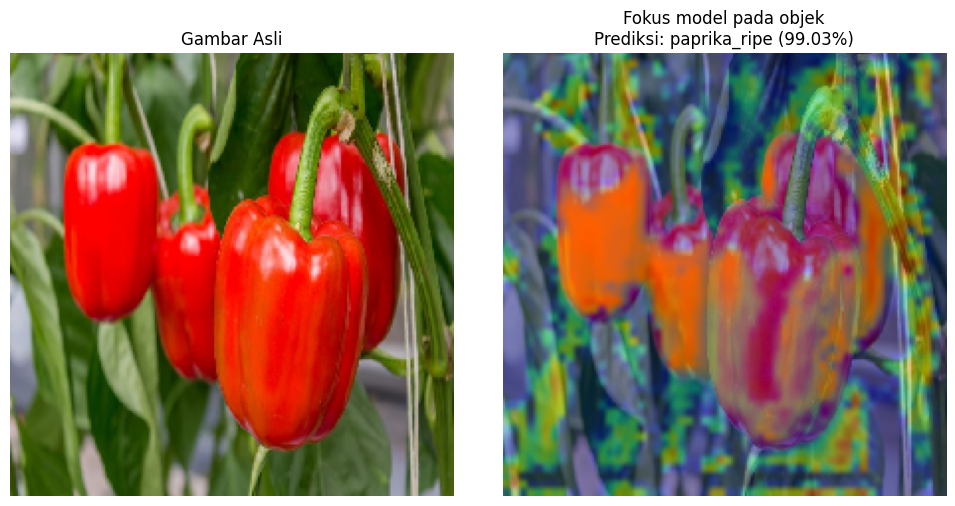

Menganalisis gambar: PAPRIKA_MENTAH.jpeg...


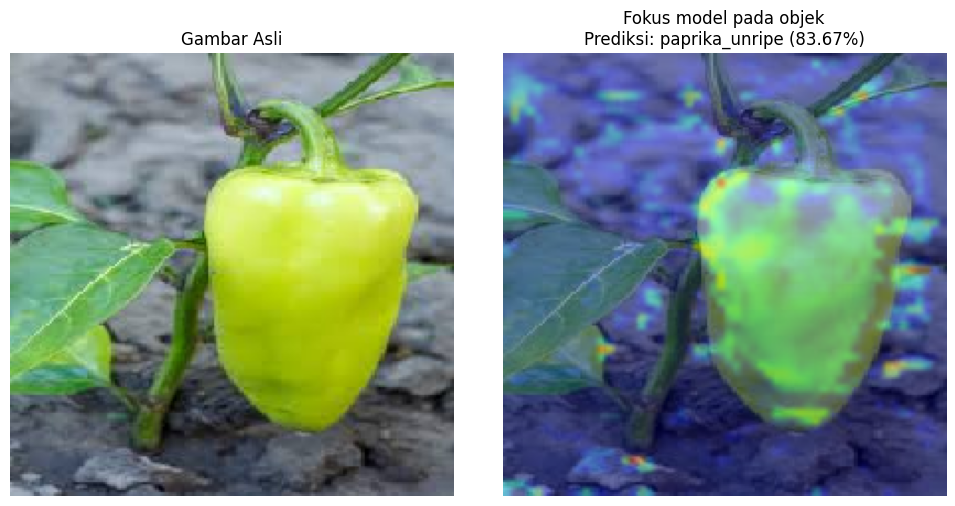

Menganalisis gambar: PAPRIKA_BUSUK.jpeg...


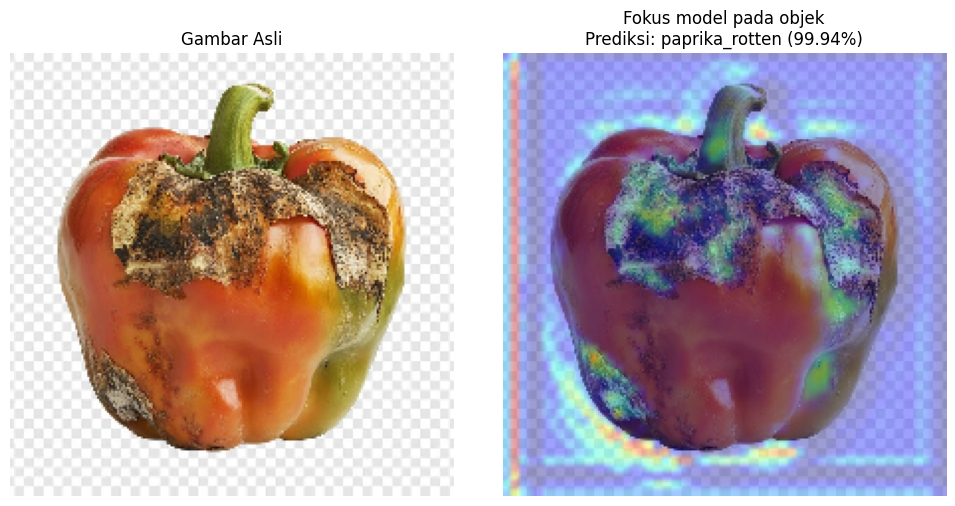

In [ ]:
# 5. Eksekusi Inference & Visualisasi (Untuk 3 Gambar)
# Masukkan nama 3 file gambar kamu ke dalam list ini!
TEST_IMAGE_PATHS = [
    "PAPRIKA_MATANG.jpeg",  # <--- Ganti dengan gambar matang
    "PAPRIKA_MENTAH.jpeg",  # <--- Ganti dengan gambar mentah
    "PAPRIKA_BUSUK.jpeg"    # <--- Ganti dengan gambar busuk
]

LAST_CONV_LAYER = "background_filter_attention"
IMG_SIZE = (224, 224)

# Pastikan urutan array ini SESUAI dengan urutan abjad folder kelas saat training
class_names = ['paprika_ripe', 'paprika_rotten', 'paprika_unripe']

print(f"\nMenjalankan Inference dan Grad-CAM Paprika untuk {len(TEST_IMAGE_PATHS)} Gambar...\n")

for path_gambar in TEST_IMAGE_PATHS:
    print(f"Menganalisis gambar: {path_gambar}...")
    try:
        # Preprocessing, Grad-CAM, dan Tampilkan
        img_tensor, original_img = get_and_preprocess_image(path_gambar, IMG_SIZE)
        heatmap, preds, pred_index = make_gradcam_heatmap(img_tensor, model_freshly_tuning, LAST_CONV_LAYER)
        display_gradcam(original_img, heatmap, preds, pred_index, class_names)

    except Exception as e:
        print(f"Gagal melakukan visualisasi pada gambar {path_gambar}. Pastikan nama file benar!")
        print(f"Detail Error: {e}")

    print("=" * 60) # Garis pemisah antar gambar agar rapi